# Decision-focused learning with quarterly PD and Basel IRB (empirical, FRED)

Empirical counterpart of `04_dfl_simulated_panel`: the DFL model of the methodology
chapter (S3.2.4) keeps the interpretable PD forecast (eq. 3.49) but trains it end-to-end
on decision regret (eq. 3.33) through the differentiable allocation layer (eq. 3.50).

This notebook is scoped to DFL only: it trains and evaluates `dfl_linear` / `dfl_mlp`
against the foresight oracle recomputed from realised outcomes (there is no Bayes oracle
for the empirical panel - see `02_pto_empirical`), on the same expanding-window protocol
used everywhere else in this project. It does **not** re-run PTO, does **not** compute a
persistence baseline, and does **not** run Diebold-Mariano tests or any cross-notebook
comparison against PTO or the black box - those live in a separate cross-model
comparison notebook that reads the per-model result CSVs each model notebook saves
(`dfl_quarterly_pd_irb_predictions_<split>.csv` here, alongside
`pto_quarterly_pd_irb_predictions_<split>.csv` from `02_pto_empirical` and
`blackbox_quarterly_pd_irb_predictions_<split>.csv` from `03_black_box_empirical`).

Data loading, alignment, the decision environment and evaluation splits (`modern`,
`stress`) are shared with `02_pto_empirical` (`load_quarterly_pd_panel` and the PD/Basel
helper functions are copied verbatim); decision and Basel constants are read from
`empirical_panel_metadata.json`, written by `02_pto_empirical`, and asserted rather than
hardcoded, so the three notebooks cannot silently diverge on the decision environment.

**The allocation layer** (see the DFL core section): forward pass solves the smooth
forecast-based objective (eq. 3.24/3.25) continuously by **bisection on the first-order
condition**; backward pass applies the closed-form implicit-function-theorem ratio
dalpha*/dpd = -(dF/dpd)/(dF/dalpha) at the optimum (zero at boundary optima). The
solver is never differentiated through - a grid argmax would make alpha*(pd) a step
function with zero gradient almost everywhere and DFL would silently fail to train; the
continuous solve is what makes the method possible, in training AND at evaluation - there
is no grid snap anywhere in this notebook. Full chain (eq. 3.52): realised regret
subgradient (eq. 3.43) x IFT ratio x network Jacobian.

The bivariate normal CDF needed for the analytical Vasicek expected shortfall
(`bvn_cdf`) uses the same Owen's-T implementation (`scipy.special.owens_t`) as every
other notebook in this project, rather than a separate Gauss-Legendre quadrature - one
shared bivariate-CDF implementation everywhere.

Empirical specifics (matching the black-box notebook): the capital requirement in the
training loss is `k_irb(pd_a_realised_{t+1})`, matching how the empirical evaluation
computes realised utility; the foresight oracle is the only oracle; regret vs perfect
foresight is the decision metric. The Vasicek correlation in the decision objective is
the Basel R evaluated at the annualised forecast (held fixed when differentiating -
documented gradient simplification, quantified in the gradient-audit cell).

**Comparability caveat for the write-up**: the empirical PTO decision rule is the
plug-in continuous rule (kinked utility at the point forecast, optimised with a bounded
scalar solver rather than a grid), while DFL necessarily decides through the smooth
expected-utility objective - the smooth objective is what makes the IFT gradient exist.
DFL therefore differs from empirical PTO in BOTH the training loss and the decision map.
The simulated comparison (notebook 04 vs 02 with `DECISION_RULE = "expected"`) isolates
the training-loss effect cleanly; interpret the empirical DFL-vs-PTO gap with that in
mind.

In [1]:
from __future__ import annotations

import json
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
from scipy.special import ndtri, owens_t
from scipy.optimize import minimize_scalar
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook needs PyTorch for the linear and MLP PTO models. "
        "Install the project requirements or select the project kernel."
    ) from exc

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "empirical" / "data" / "fred_loan_return_aligned.csv").exists():
    ROOT = ROOT.parent

import sys
sys.path.insert(0, str(ROOT))
from minou_colors import MINOU_COLORS
FIGURES_DIR = ROOT / "empirical" / "figures" / "dfl"
RESULTS_DIR = ROOT / "empirical" / "results" / "dfl"
METADATA_PATH = ROOT / "empirical" / "data" / "empirical_panel_metadata.json"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Project root: {ROOT}")
print(f"Figures: {FIGURES_DIR.relative_to(ROOT)}")
print(f"Results: {RESULTS_DIR.relative_to(ROOT)}")

Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Figures: empirical/figures/dfl
Results: empirical/results/dfl


## Configuration

Decision and Basel constants (`LGD`, `M`, `K1`, `LEVERAGE`, `Y_BAR`, `LAMBDA`, the PD
floor) are read from `empirical_panel_metadata.json` (written by `02_pto_empirical`) and
asserted against the expected calibration, so this notebook cannot silently diverge from
the PTO notebook. `CHARGE_OFF_CONVERSION = "simple"` inverts FRED's simple x4
annualisation, which is the correct inverse for these series. Allocation decisions are
optimised continuously everywhere (`ALPHA_BOUNDS`, `ALPHA_OPT_XATOL` for the recomputed
oracle; bisection on the FOC for DFL's own decision) - there is no grid anywhere in this
notebook. `DFL_SEEDS` / `DFL_MODEL_CFG` pin DFL to the same seed-ensemble effort and
capacity/optimiser/early-stopping budget as the PTO MLP in `02_pto_empirical` (fairness
rule), even though PTO itself is not re-run here.

In [12]:
# Data conventions
HORIZON = 1
DATE_COL = "DATE"
TARGET_COL = "charge_off_rate"

# Feature policy: the current-quarter charge-off c_q is realised by decision time
# (start of t+1), modulo a reporting lag. Set False to revert to lag-1 only.
INCLUDE_CURRENT_CQ = True

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    META = json.load(f)
CONST = META["constants"]

# Decision and Basel constants (from 02_pto_empirical's metadata, asserted not assumed)
CHARGE_OFF_IS_PERCENT = bool(CONST["CHARGE_OFF_IS_PERCENT"])
CHARGE_OFF_CONVERSION = str(CONST["CHARGE_OFF_CONVERSION"])
LGD = float(CONST["LGD"])
M = float(CONST["M"])
K1 = float(CONST["K1"])
LEVERAGE = float(CONST["ell"])
Y_BAR = float(CONST["Y_BAR"])
LAMBDA = float(CONST["lambda_shortfall"])
APPLY_PD_FLOOR = bool(CONST["APPLY_PD_FLOOR"])
PD_FLOOR = float(CONST["PD_FLOOR"])
assert LGD == 0.45 and K1 == 1.0 and LEVERAGE == 10.0, "Panel constants differ from expected calibration."
assert bool(CONST["INCLUDE_CURRENT_CQ"]) == INCLUDE_CURRENT_CQ, \
    "INCLUDE_CURRENT_CQ differs from the PTO notebook's panel metadata."

PD_Q_CLIP_LOW = float(CONST["PD_CLIP_LOW"])
PD_Q_CLIP_HIGH = float(CONST["PD_CLIP_HIGH"])
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99

# Allocation decisions are optimised continuously on [0, 1] (a bounded scalar solver for
# the recomputed oracle; bisection on the FOC for DFL's own decision) rather than snapped
# to a discrete grid - there is no grid anywhere in this notebook.
ALPHA_BOUNDS = (float(CONST["alpha_bounds_min"]), float(CONST["alpha_bounds_max"]))
ALPHA_OPT_XATOL = float(CONST["alpha_opt_xatol"])

# Evaluation splits: separate expanding-window experiments (same as 02_pto_empirical).
EVAL_SPLITS = {
    #"modern": {"initial_train_frac": 0.75},
    "stress": {"first_test_date": "2006-01-01"},
}

@dataclass
class ModelConfig:
    hidden_dim: int = 16
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 16
    epochs: int = 500
    patience: int = 75
    val_frac: float = 0.2
    seed: int = 42

# ---- DFL specifics -----------------------------------------------------------------------
# DFL keeps the PD forecaster and trains it on realised regret through the implicit
# allocation layer (smooth objective + bisection forward, closed-form IFT backward; see
# the DFL core section). Same ModelConfig field values as 02_pto_empirical's MODEL_CFG
# (fairness rule): no model gets a different training budget.
DFL_MODEL_CFG = ModelConfig()
DFL_SEEDS = (42, 43, 44, 45, 46)  # same seed-ensemble effort as the PTO MLP
DFL_ALPHA_LO = 1e-4             # lower bisection bracket (alpha* = 0 handled as boundary)
DFL_BISECT_ITERS = 30           # bracket halves 60x: alpha* to ~1e-18, far tighter than any grid
DFL_FD_REL = 1e-5               # relative step for the K'_IRB central finite difference
DFL_GRAD_CLIP = 1e3             # safety clamp on |dalpha*/dpd| (thresholds near support edge)

print(f"Constants from metadata: LGD={LGD}, LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}, "
      f"PD floor={PD_FLOOR} (applied={APPLY_PD_FLOOR})")
print(f"DFL: PD forecaster trained on realised regret through the implicit allocation layer "
      f"(bisection + IFT); seeds {DFL_SEEDS}; same ModelConfig as PTO; rho held fixed in the gradient.")

Constants from metadata: LGD=0.45, LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0, PD floor=0.0003 (applied=True)
DFL: PD forecaster trained on realised regret through the implicit allocation layer (bisection + IFT); seeds (42, 43, 44, 45, 46); same ModelConfig as PTO; rho held fixed in the gradient.


## Assumptions and caveats

These are held fixed by design; each materially shapes the results and should be restated
wherever results are reported.

- **Constant LGD = 0.45.** Realised PD is backed out as `c_q / LGD`, so "PD" here is a
  rescaled charge-off rate. LGD is procyclical in reality and Basel requires downturn LGD.
- **Corporate IRB curve on an aggregate charge-off series.** The asset-correlation function,
  maturity adjustment, and 0.03% floor are the wholesale/corporate ones. If the underlying
  FRED series is retail/consumer, the retail risk-weight functions (different correlation,
  no maturity adjustment) would apply.
- **Point-in-time PD in a through-the-cycle formula.** Next-quarter PD is annualised as
  `1-(1-pd_q)^4` (independence across quarters) and fed into the IRB formula, making capital
  procyclical; Basel intends TTC PDs.
- **Constant quarterly yield `Y_BAR` and constant leverage** regardless of the rate
  environment.
- **Final-vintage macro data.** Features use revised series, and quarter-t values (e.g. GDP)
  are not published until well into t+1 — a mild look-ahead relative to real-time
  deployment. Including `c_q` as a feature likewise assumes the quarter-t charge-off is
  observable at decision time; set `INCLUDE_CURRENT_CQ = False` to enforce a full
  one-quarter reporting lag.
- **Oracle regret** uses per-period perfect foresight of both `c_q` and the annualised PD
  entering the capital requirement, so regret mixes forecast error with capital-requirement
  foresight.
- **Capital buffer add-on.** Committed capital is excluded from the available buffer;
  equivalently the requirement is `K_IRB + 1/LEVERAGE` per unit exposure, i.e. the
  regulatory minimum plus a fixed management buffer. Calibrated so the constraint binds
  in the interior of the allocation range - without it the constraint never binds for
  alpha in [0,1] and the decision is degenerate at alpha = 1.
- **DFL training signal is hindsight-outcome information only**: per training sample it
  uses realised `c_q_{t+1}`, the realised annualised PD's IRB charge
  `k_irb(pd_a_realised_{t+1})`, and the foresight-oracle utility - the identical
  training signal to the black-box benchmark, and the same information status as PTO
  training on realised `c_{t+1}/LGD`. Targets only; features identical across models.
- **DFL decides through the smooth expected-utility objective, solved continuously**
  (bisection on the FOC; grid snap at evaluation only). The empirical PTO decision rule
  remains the plug-in grid rule, so empirical DFL-vs-PTO differences mix the training
  loss and the decision map - see the header caveat; the simulated notebooks isolate
  the training-loss effect.
- **Correlation channel omitted from the gradient**: rho = BaselR(pd_a_hat) is held
  fixed at its evaluated value when differentiating (forward pass exact; audited below).
  K'_IRB uses a central finite difference on the composite quarterly -> annualised ->
  Basel map (annualisation chain 4(1-pd)^3 included automatically).

## Quarterly PD, Basel IRB, and allocation objective

In [13]:
def annual_chargeoff_to_quarterly(c_annual, conversion=CHARGE_OFF_CONVERSION):
    c_annual = np.asarray(c_annual, dtype=float)
    if conversion == "compound":
        return 1.0 - np.power(1.0 - c_annual, 1.0 / 4.0)
    if conversion == "simple":
        return c_annual / 4.0
    raise ValueError("CHARGE_OFF_CONVERSION must be 'compound' or 'simple'.")


def clip_pd_q(pd_q):
    return np.clip(np.asarray(pd_q, dtype=float), PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)


def clip_pd_a(pd_a):
    return np.clip(np.asarray(pd_a, dtype=float), PD_A_CLIP_LOW, PD_A_CLIP_HIGH)


def quarterly_pd_to_annual(pd_q):
    pd_q = clip_pd_q(pd_q)
    return clip_pd_a(1.0 - np.power(1.0 - pd_q, 4.0))


def k_irb_from_annual_pd(pd_a, lgd=LGD, m=M, apply_floor=APPLY_PD_FLOOR):
    # Basel IRB capital requirement per unit exposure. Input must be annual PD.
    pd_a = clip_pd_a(pd_a)
    if apply_floor:
        pd_a = np.maximum(pd_a, PD_FLOOR)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    r = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
    b = np.square(0.11852 - 0.05478 * np.log(pd_a))
    maturity_adj = (1.0 + (m - 2.5) * b) / (1.0 - 1.5 * b)
    z = norm.ppf(pd_a) / np.sqrt(1.0 - r) + np.sqrt(r / (1.0 - r)) * norm.ppf(0.999)
    k_irb = lgd * (norm.cdf(z) - pd_a) * maturity_adj
    return np.maximum(k_irb, 0.0)


def allocation_utility(alpha, c_q, pd_a, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1, lgd=LGD, m=M):
    # U(alpha; c_q, pd_a), with pd_a used only for Basel IRB capital.
    # Buffer semantics (intentional): committed capital alpha*k1 is excluded from the
    # available buffer. Algebraically identical to requiring K_IRB plus a fixed
    # management buffer add-on of 1/LEVERAGE per unit exposure; this is what makes the
    # capital constraint bind in the interior of the alpha domain (without it the
    # constraint never binds on [0,1] and every model would choose alpha = 1).
    alpha = np.asarray(alpha, dtype=float)
    c_q = float(c_q)
    pd_a = float(clip_pd_a(pd_a))
    exposure = leverage * alpha * k1
    terminal_capital = k1 + exposure * (y_bar - c_q)
    committed_capital = alpha * k1
    available_buffer = terminal_capital - committed_capital
    required_capital = k_irb_from_annual_pd(pd_a, lgd=lgd, m=m) * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    return terminal_capital - lambda_penalty * shortfall


def decision_components(alpha, c_q, pd_a):
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    k_irb = float(k_irb_from_annual_pd(pd_a))
    required_capital = k_irb * exposure
    shortfall = max(required_capital - available_buffer, 0.0)
    utility = terminal_capital - LAMBDA * shortfall
    return dict(exposure=exposure, terminal_capital=terminal_capital, committed_capital=committed_capital,
                available_buffer=available_buffer, required_capital=required_capital, shortfall=shortfall,
                utility=utility, k_irb=k_irb)


def optimise_alpha_continuous(c_q, pd_a):
    """Continuous optimum of allocation_utility(alpha; c_q, pd_a) on [0, 1] - used for the
    foresight oracle here (recomputed from realised outcomes; verbatim from
    02_pto_empirical). Brent's method via scipy.optimize.minimize_scalar, bounded on
    ALPHA_BOUNDS with tolerance ALPHA_OPT_XATOL; both domain boundaries are checked
    explicitly."""
    def neg_utility(alpha):
        return -float(allocation_utility(alpha, c_q=c_q, pd_a=pd_a))

    opt = minimize_scalar(neg_utility, bounds=ALPHA_BOUNDS, method="bounded",
                           options={"xatol": ALPHA_OPT_XATOL})
    candidates = [(0.0, -neg_utility(0.0)), (1.0, -neg_utility(1.0)), (float(opt.x), -float(opt.fun))]
    return max(candidates, key=lambda item: item[1])

## Load and align data

The forecasting row is `x_t -> PD_Q_{t+1}`; result columns are named for the realised
next-period outcome, because that is the period used for decision evaluation.

Features now include the current-quarter charge-off `c_q` (realised by decision time,
subject to a reporting lag — see the assumptions cell) alongside `c_q_lag1`. Constructed PD
columns (`pd_q`, `pd_a`) remain excluded: realised PD is built from charge-offs for the
target/evaluation convention, not treated as an observed signal.
After loading, the per-quarter foresight oracle (`alpha_oracle_next`,
`utility_oracle_next`) and the realised IRB charge `k_irb_realised_next` are precomputed
once: they are the DFL model's training signal and are identical to the quantities
`build_result_row` recomputes per test row.


In [14]:
def load_quarterly_pd_panel(macro_csv, chargeoff_csv, date_col=DATE_COL, target_col=TARGET_COL, feature_cols=None, horizon=HORIZON):
    macro = pd.read_csv(macro_csv)
    charge = pd.read_csv(chargeoff_csv)
    macro[date_col] = pd.to_datetime(macro[date_col]).dt.to_period("Q").dt.start_time
    charge[date_col] = pd.to_datetime(charge[date_col]).dt.to_period("Q").dt.start_time

    if target_col not in charge.columns:
        raise ValueError(f"{target_col!r} not found in charge-off columns: {list(charge.columns)}")

    charge["c_annual_raw"] = pd.to_numeric(charge[target_col], errors="coerce")
    charge["c_annual_decimal"] = charge["c_annual_raw"] / 100.0 if CHARGE_OFF_IS_PERCENT else charge["c_annual_raw"]
    charge["c_q"] = annual_chargeoff_to_quarterly(charge["c_annual_decimal"].to_numpy())
    charge["pd_q"] = clip_pd_q(charge["c_q"].to_numpy() / LGD)
    charge["pd_a"] = quarterly_pd_to_annual(charge["pd_q"].to_numpy())

    keep_charge = [date_col, "c_annual_raw", "c_annual_decimal", "c_q", "pd_q", "pd_a"]
    df = pd.merge(macro, charge[keep_charge], on=date_col, how="inner").sort_values(date_col).reset_index(drop=True)

    # Observed autoregressive signals. PD columns are never features.
    df["c_q_lag1"] = df["c_q"].shift(1)

    df["target_date"] = df[date_col].shift(-horizon)
    df["c_annual_raw_next"] = df["c_annual_raw"].shift(-horizon)
    df["c_q_realised"] = df["c_q"].shift(-horizon)
    df["pd_q_realised"] = df["pd_q"].shift(-horizon)
    df["pd_a_realised"] = df["pd_a"].shift(-horizon)
    df["target_pd_q_next"] = df["pd_q_realised"]

    if feature_cols is None:
        exclude = {date_col, "c_annual_raw", "c_annual_decimal", "pd_q", "pd_a", "target_date",
                   "c_annual_raw_next", "c_q_realised", "pd_q_realised", "pd_a_realised", "target_pd_q_next"}
        if not INCLUDE_CURRENT_CQ:
            exclude.add("c_q")
        feature_cols = [c for c in df.columns if c not in exclude]
    else:
        feature_cols = list(feature_cols)

    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    required = feature_cols + ["c_q", "target_date", "c_annual_raw_next", "c_q_realised", "pd_q_realised", "pd_a_realised", "target_pd_q_next"]
    required = list(dict.fromkeys(required))
    df = df.dropna(subset=required).reset_index(drop=True)
    if len(df) < 30:
        raise ValueError(f"Only {len(df)} usable observations after alignment; check dates and missing values.")
    df.attrs["feature_cols"] = feature_cols
    return df

macro_csv = ROOT / "empirical" / "data" / "macro_panel_quarterly.csv"
chargeoff_csv = ROOT / "empirical" / "data" / "fred_loan_return_aligned.csv"
df = load_quarterly_pd_panel(macro_csv, chargeoff_csv)
feature_cols = df.attrs["feature_cols"]

print(f"Observations after alignment and one-step target: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Target date range: {df['target_date'].min().date()} to {df['target_date'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
assert "c_q_lag1" in feature_cols
assert ("c_q" in feature_cols) == INCLUDE_CURRENT_CQ
assert not any(col.startswith("pd_q") or col.startswith("pd_a") for col in feature_cols)
print(f"Lag features included: c_q_lag1{' and current-quarter c_q' if INCLUDE_CURRENT_CQ else ''}; PD columns excluded.")
display(df.head())

# Foresight-oracle allocation and utility per TARGET quarter (perfect hindsight of
# c_q_{t+1} and pd_a_realised_{t+1}; identical to build_result_row's recomputation).
# Hindsight-outcome information: used only as the DFL model's training signal, never as
# a feature.
_oracle = [optimise_alpha_continuous(c_q=float(c), pd_a=float(p))
           for c, p in zip(df["c_q_realised"], df["pd_a_realised"])]
df["alpha_oracle_next"] = [a for a, _ in _oracle]
df["utility_oracle_next"] = [u for _, u in _oracle]
# Capital requirement entering the DFL training loss: the realised annualised PD's
# IRB charge, matching how the empirical evaluation computes realised utility.
df["k_irb_realised_next"] = k_irb_from_annual_pd(df["pd_a_realised"].to_numpy())
assert not set(["alpha_oracle_next", "utility_oracle_next", "k_irb_realised_next"]) & set(feature_cols)
print("Precomputed foresight oracle and realised K_IRB for the DFL training signal.")


Observations after alignment and one-step target: 142
Feature date range: 1990-07-01 to 2025-10-01
Target date range: 1990-10-01 to 2026-01-01
Features (14): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium', 'c_q', 'c_q_lag1']
Lag features included: c_q_lag1 and current-quarter c_q; PD columns excluded.


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,...,c_q,pd_q,pd_a,c_q_lag1,target_date,c_annual_raw_next,c_q_realised,pd_q_realised,pd_a_realised,target_pd_q_next
0,1990-07-01,0.3,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,...,0.003200,0.007111,0.028142,0.003575,1990-10-01,1.30,0.003250,0.007222,0.028577,0.007222
1,1990-10-01,-3.6,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,...,0.003250,0.007222,0.028577,0.003200,1991-01-01,1.48,0.003700,0.008222,0.032485,0.008222
2,1991-01-01,-1.9,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,...,0.003700,0.008222,0.032485,0.003250,1991-04-01,1.86,0.004650,0.010333,0.040697,0.010333
3,1991-04-01,3.2,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,...,0.004650,0.010333,0.040697,0.003700,1991-07-01,1.97,0.004925,0.010944,0.043064,0.010944
4,1991-07-01,2.0,6.866667,1.390822,0.383417,0.759342,0.195457,5.643333,1.428906,16.634219,...,0.004925,0.010944,0.043064,0.004650,1991-10-01,1.83,0.004575,0.010167,0.040051,0.010167


Precomputed foresight oracle and realised K_IRB for the DFL training signal.


## DFL forecaster architecture

Identical PD-forecaster architecture used across the project (raw-score output whose
sigmoid is the predicted quarterly PD, bias initialised from the pre-validation slice,
chronological train/validation split with shuffled mini-batches, early stopping, MLP
seed ensemble) - only the loss differs from a PTO predictor: DFL trains on realised
regret through the implicit allocation layer defined in the next section, not on a PD
prediction loss (so the PTO notebook's `LOSS` / `NLL_*` / `TARGET_TRANSFORM` switches do
not apply here).

In [15]:
class PDForecaster(nn.Module):
    # Outputs a raw score; predicted quarterly PD is sigmoid(score). Same linear /
    # two-hidden-layer MLP bodies used for the PTO forecaster in 02_pto_empirical
    # (fairness rule: identical architecture and capacity).
    def __init__(self, input_dim, model_type, hidden_dim=16):
        super().__init__()
        if model_type == "linear":
            self.net = nn.Linear(input_dim, 1)
        elif model_type == "mlp":
            self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                                     nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        else:
            raise ValueError("model_type must be 'linear' or 'mlp'.")

    def forward(self, x):
        return self.net(x).squeeze(-1)


def init_output_bias_for_target(model, y_pre_val):
    # Bias starts at logit(mean PD) of the PRE-validation slice only, so validation
    # targets used for early stopping never influence initialisation.
    y_mean = float(np.clip(np.mean(y_pre_val), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW))
    logit_mean = float(np.log(y_mean / (1.0 - y_mean)))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def predict_pd_q(model, x):
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(torch.tensor(x, dtype=torch.float32))).cpu().numpy()
    return clip_pd_q(np.atleast_1d(pred))


def predict_pd_q_ensemble(models, x):
    preds = np.stack([predict_pd_q(m, x) for m in models], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)

## DFL core: smooth objective, bisection forward pass, IFT backward pass

The cell below implements the differentiable allocation layer:

- `dfl_smooth_utility` / `dfl_foc`: the forecast-based objective U_hat(alpha; pd) (thesis
  eq. 3.24) and its first-order condition F = dU_hat/dalpha, in closed form via the
  Vasicek expected shortfall ES = Phi2(ndtri(pd), y_x; sqrt(rho)) - x Phi(y_x)
  (eq. 3.26-3.28; `bvn_cdf` is the same Owen's-T bivariate normal CDF used everywhere
  else in this project, not a separate quadrature implementation);
- `solve_alpha_star`: vectorised bisection on F = 0. F is strictly decreasing wherever
  the Vasicek density at the threshold is positive (d2U/dalpha2 =
  -lambda f_L(x) / (ell alpha^3 LGD) < 0), so endpoint sign checks detect boundary
  optima (F(1) >= 0 -> alpha* = 1; F(lo) <= 0 -> alpha* = 0) and bisection converges to
  the unique interior root otherwise. The same call returns the closed-form IFT
  gradient dalpha*/dpd (zero at boundaries), assembled from: the threshold channel
  via K'_IRB (central finite difference on the composite quarterly -> annualised ->
  Basel map, annualisation chain 4(1-pd)^3 included), the distribution-mean channel
  via Psi = Phi((y_x - sqrt(rho) ndtri(pd)) / sqrt(1-rho)) and the exceedance-density
  term, with rho held fixed (documented simplification);
- `ImplicitAllocation`: the torch autograd wrapper - non-differentiable bisection in
  forward, the IFT ratio in backward;
- `train_dfl_model` / `train_dfl_ensemble`: identical mechanics to the black-box
  training loop (chronological validation split, shuffled mini-batches, early stopping
  on validation regret, same ModelConfig and seed ensemble), with the network output
  read as a PD forecast and passed through the implicit layer.

There is no grid snap anywhere - the continuous bisection optimum is used directly both
during training (where it must be, for the gradient to exist) and at evaluation.

In [16]:
def torch_allocation_utility(alpha, c_q, k):
    """Differentiable realised utility - same constants and the same intentional buffer
    semantics as allocation_utility (committed capital alpha*K1 excluded from the buffer).
    The kinked shortfall max(., 0) is piecewise linear; torch subgradients handle it
    (thesis eq. 3.43: the realised regret subgradient shared by BB and DFL)."""
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k * exposure
    shortfall = torch.clamp(required_capital - available_buffer, min=0.0)
    return terminal_capital - LAMBDA * shortfall


# ---------------------------------------------------------------------------------------
# DFL core: smooth forecast-based objective, bisection forward pass, IFT backward pass.
#
# Forward decision map (thesis eq. 3.24/3.25): given the model's own quarterly PD forecast,
#   alpha*(pd_q) = argmax_alpha  1 + ell*alpha*(y_bar - LGD*pd_q)
#                              - lambda*ell*alpha*LGD * E[(L - x(alpha, pd_q))^+]
# with L ~ Vasicek(pd_q, rho), rho = DFL_RHO_SCALE * BaselR(pd_a(pd_q)) (matching the
# simulator / expected-utility PTO convention), and threshold
#   x(alpha, pd_q) = ((1 - alpha) + ell*alpha*(y_bar - k)) / (ell*alpha*LGD),
#   k = K_IRB(pd_a(pd_q)).
# The optimum solves the FOC F(alpha, pd_q) = 0 with
#   F = ell*(y_bar - LGD*pd_q) - lambda*ell*LGD*ES(x; pd_q, rho) - (lambda/alpha)*P(L > x).
# F is strictly decreasing where the Vasicek density at the threshold is positive
# (d2U/dalpha2 = -lambda * f_L(x) / (ell * alpha^3 * LGD) < 0), so a sign check at the
# brackets detects boundary solutions and bisection finds the unique interior root.
#
# Backward pass (implicit function theorem on the FOC):
#   dalpha*/dpd = - (dF/dpd) / (dF/dalpha) |_(alpha*)     [zero at boundary solutions]
#   dF/dalpha = -lambda * f_L(x) / (ell * alpha^3 * LGD)
#   dF/dpd    = -ell*LGD - lambda*ell*LGD*( P(L>x)*Kp/LGD + Psi )
#               - (lambda/alpha)*( f_L(x)*Kp/LGD + phi(y_x)/(sqrt(rho)*phi(ndtri(pd))) )
# where Kp = d K_IRB(pd_a(pd_q)) / d pd_q (central finite difference on the composite
# quarterly -> annual -> Basel map), and
#   Psi = Phi( (y_x - sqrt(rho)*ndtri(pd)) / sqrt(1-rho) )  in (0,1)
# is dES/dpd at fixed threshold (the y_x-channel terms cancel identically).
# Simplification (documented in the thesis): rho is held fixed at its evaluated value
# when differentiating; the correlation channel R'(pd) is omitted from the gradient.
# The forward pass always evaluates the exact rho.
# ---------------------------------------------------------------------------------------
_ndtri = ndtri  # local alias, kept for minimal diff against the rest of this cell

DFL_RHO_SCALE = float(globals().get("RHO_SCALE", 1.0))
_X_EPS = 1e-9          # threshold considered outside (0,1) beyond this
_PD_LO, _PD_HI = PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH


def dfl_basel_r_annual(pd_a):
    pd_a = clip_pd_a(pd_a)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    return 0.12 * exp_term + 0.24 * (1.0 - exp_term)


def dfl_rho(pd_a):
    return np.clip(DFL_RHO_SCALE * dfl_basel_r_annual(pd_a), 1e-4, 0.999)


def bvn_cdf(a, b, r):
    """Bivariate standard normal CDF Phi2(a, b; r), vectorised, elementwise r, via
    Owen's T function (Owen, 1956) - identical implementation to bivariate_normal_cdf /
    bvn_cdf in every other notebook in this project (one shared bivariate-CDF machinery,
    not a mix of Owen's T and Gauss-Legendre quadrature).
    Phi2(h, k; rho) = 1/2*(Phi(h) + Phi(k)) - T(h, a) - T(k, b) - delta, with
    a = (k/h - rho) / sqrt(1 - rho^2), b = (h/k - rho) / sqrt(1 - rho^2), and
    delta = 0 if h*k > 0 (or h*k == 0 and h + k >= 0), else 1/2. Known degenerate point:
    h == k == 0 returns double the correct value (division-by-zero guard collapses both
    Owen's-T terms to the same limit) - deliberately not special-cased, since h = k = 0
    is a measure-zero event with continuous PD/threshold data and never occurs here.
    This function is only ever used for the forward FOC value; the IFT gradient below
    does not call it."""
    h = np.atleast_1d(np.asarray(a, dtype=float))
    k = np.atleast_1d(np.asarray(b, dtype=float))
    rho = np.clip(np.atleast_1d(np.asarray(r, dtype=float)), -0.999999, 0.999999)
    denom = np.sqrt(np.maximum(1.0 - rho ** 2, 1e-300))
    h_safe = np.where(h == 0.0, 1e-12, h)
    k_safe = np.where(k == 0.0, 1e-12, k)
    aa = (k / h_safe - rho) / denom
    bb = (h / k_safe - rho) / denom
    val = 0.5 * (norm.cdf(h) + norm.cdf(k)) - owens_t(h_safe, aa) - owens_t(k_safe, bb)
    hk = h * k
    delta = np.where((hk > 0.0) | ((hk == 0.0) & (h + k >= 0.0)), 0.0, 0.5)
    return val - delta


def dfl_threshold_x(alpha, k):
    return ((1.0 - alpha) + LEVERAGE * alpha * (Y_BAR - k)) / (LEVERAGE * alpha * LGD)


def vasicek_es_exceed(x, pd_q, rho):
    """Closed-form E[(L-x)^+] and P(L > x) under Vasicek(pd_q, rho); handles thresholds
    outside (0,1): x <= 0 -> hinge always active (ES = pd - x, P = 1); x >= 1 -> never
    active (ES = 0, P = 0). Returns (ES, P, y_x, inside_mask)."""
    x = np.atleast_1d(np.asarray(x, dtype=float))
    pd_q = np.atleast_1d(np.asarray(pd_q, dtype=float))
    rho = np.atleast_1d(np.asarray(rho, dtype=float))
    a = _ndtri(np.clip(pd_q, _PD_LO, 1.0 - _PD_LO))
    inside = (x > _X_EPS) & (x < 1.0 - _X_EPS)
    x_in = np.clip(x, _X_EPS, 1.0 - _X_EPS)
    y_x = (a - np.sqrt(1.0 - rho) * _ndtri(x_in)) / np.sqrt(rho)
    p_in = norm.cdf(y_x)
    es_in = bvn_cdf(a, y_x, np.sqrt(rho)) - x_in * p_in
    es = np.where(inside, es_in, np.where(x <= _X_EPS, pd_q - x, 0.0))
    p = np.where(inside, p_in, np.where(x <= _X_EPS, 1.0, 0.0))
    return es, p, y_x, inside


def vasicek_pdf(x, pd_q, rho):
    """Vasicek default-rate density f_L(x; pd_q, rho) (thesis eq. 3.7); 0 outside (0,1)."""
    x = np.atleast_1d(np.asarray(x, dtype=float))
    pd_q = np.atleast_1d(np.asarray(pd_q, dtype=float))
    rho = np.atleast_1d(np.asarray(rho, dtype=float))
    inside = (x > _X_EPS) & (x < 1.0 - _X_EPS)
    x_in = np.clip(x, _X_EPS, 1.0 - _X_EPS)
    a = _ndtri(np.clip(pd_q, _PD_LO, 1.0 - _PD_LO))
    xi = _ndtri(x_in)
    dens = (np.sqrt((1.0 - rho) / rho)
            * np.exp(-((np.sqrt(1.0 - rho) * xi - a) ** 2) / (2.0 * rho) + 0.5 * xi ** 2))
    return np.where(inside, dens, 0.0)


def dfl_smooth_utility(alpha, pd_q, k, rho):
    """Forecast-based expected utility U_hat(alpha; pd_q) (thesis eq. 3.24), closed form."""
    x = dfl_threshold_x(alpha, k)
    es, _, _, _ = vasicek_es_exceed(x, pd_q, rho)
    return (K1 + LEVERAGE * alpha * (Y_BAR - LGD * pd_q)
            - LAMBDA * LEVERAGE * alpha * LGD * es)


def dfl_foc(alpha, pd_q, k, rho):
    """F(alpha, pd_q) = dU_hat/dalpha."""
    x = dfl_threshold_x(alpha, k)
    es, p, _, _ = vasicek_es_exceed(x, pd_q, rho)
    return (LEVERAGE * (Y_BAR - LGD * pd_q)
            - LAMBDA * LEVERAGE * LGD * es - (LAMBDA / alpha) * p)


def dfl_context(pd_q):
    """Per-sample constants: annual PD, K_IRB, rho, and the composite derivative
    Kp = dK_IRB(pd_a(pd_q))/dpd_q by central finite difference (annualisation chain
    4(1-pd_q)^3 included automatically by differencing the composite map)."""
    pd_q = clip_pd_q(pd_q)
    pd_a = quarterly_pd_to_annual(pd_q)
    k = k_irb_from_annual_pd(pd_a)
    rho = dfl_rho(pd_a)
    h = np.maximum(1e-8, DFL_FD_REL * pd_q)
    k_up = k_irb_from_annual_pd(quarterly_pd_to_annual(pd_q + h))
    k_dn = k_irb_from_annual_pd(quarterly_pd_to_annual(pd_q - h))
    kp = (k_up - k_dn) / (2.0 * h)
    return pd_a, k, rho, kp


def solve_alpha_star(pd_q):
    """Vectorised forward + backward pass of the implicit allocation layer.
    Returns (alpha_star, dalpha_dpd). Boundary solutions get zero gradient.
    F is strictly decreasing in alpha wherever f_L(x) > 0 (strict concavity of U_hat),
    so: F(lo) <= 0 -> alpha* = 0; F(1) >= 0 -> alpha* = 1; else bisection on the
    unique interior root."""
    pd_q = clip_pd_q(np.atleast_1d(np.asarray(pd_q, dtype=float)))
    n = pd_q.shape[0]
    _, k, rho, kp = dfl_context(pd_q)

    lo = np.full(n, DFL_ALPHA_LO)
    hi = np.ones(n)
    f_lo = dfl_foc(lo, pd_q, k, rho)
    f_hi = dfl_foc(hi, pd_q, k, rho)
    at_one = f_hi >= 0.0
    at_zero = (~at_one) & (f_lo <= 0.0)
    interior = ~(at_one | at_zero)

    a_lo, a_hi = lo.copy(), hi.copy()
    for _ in range(DFL_BISECT_ITERS):
        mid = 0.5 * (a_lo + a_hi)
        f_mid = dfl_foc(mid, pd_q, k, rho)
        go_up = f_mid > 0.0
        a_lo = np.where(interior & go_up, mid, a_lo)
        a_hi = np.where(interior & ~go_up, mid, a_hi)
    alpha = np.where(at_one, 1.0, np.where(at_zero, 0.0, 0.5 * (a_lo + a_hi)))

    # IFT gradient at the interior optimum (zero at boundaries).
    a_safe = np.clip(alpha, DFL_ALPHA_LO, 1.0)
    x = dfl_threshold_x(a_safe, k)
    es, p, y_x, inside = vasicek_es_exceed(x, pd_q, rho)
    f_l = vasicek_pdf(x, pd_q, rho)
    a_probit = _ndtri(np.clip(pd_q, _PD_LO, 1.0 - _PD_LO))
    psi = np.where(inside, norm.cdf((y_x - np.sqrt(rho) * a_probit) / np.sqrt(1.0 - rho)),
                   np.where(x <= _X_EPS, 1.0, 0.0))
    dF_dalpha = -LAMBDA * f_l / (LEVERAGE * a_safe ** 3 * LGD)
    phi_a = np.maximum(norm.pdf(a_probit), 1e-300)
    dist_term = np.where(inside, norm.pdf(y_x) / (np.sqrt(rho) * phi_a), 0.0)
    dF_dpd = (-LEVERAGE * LGD
              - LAMBDA * LEVERAGE * LGD * (p * kp / LGD + psi)
              - (LAMBDA / a_safe) * (f_l * kp / LGD + dist_term))
    with np.errstate(divide="ignore", invalid="ignore"):
        grad = np.where(interior & (np.abs(dF_dalpha) > 1e-300), -dF_dpd / dF_dalpha, 0.0)
    grad = np.clip(np.nan_to_num(grad, nan=0.0, posinf=0.0, neginf=0.0),
                   -DFL_GRAD_CLIP, DFL_GRAD_CLIP)
    return alpha, grad


class ImplicitAllocation(torch.autograd.Function):
    """Differentiable allocation layer: forward solves the FOC by bisection; backward
    multiplies the incoming gradient by the closed-form IFT ratio dalpha*/dpd.
    The solver is never differentiated through: the gradient exists in closed form (the
    implicit function theorem on the FOC), so a non-differentiable root-finder in the
    forward pass is fine."""

    @staticmethod
    def forward(ctx, pd_q_tensor):
        pd_np = pd_q_tensor.detach().cpu().numpy().astype(float).ravel()
        alpha, grad = solve_alpha_star(pd_np)
        ctx.save_for_backward(torch.as_tensor(grad, dtype=pd_q_tensor.dtype))
        return torch.as_tensor(alpha, dtype=pd_q_tensor.dtype).reshape(pd_q_tensor.shape)

    @staticmethod
    def backward(ctx, grad_output):
        (dalpha_dpd,) = ctx.saved_tensors
        return grad_output * dalpha_dpd.reshape(grad_output.shape)


def implicit_alpha(pd_q_tensor):
    return ImplicitAllocation.apply(pd_q_tensor)


def train_dfl_model(x_train, y_train_pd_q, c_next, k_next, u_oracle_next, model_type,
                    model_cfg, seed=None, return_history=False):
    """DFL training: identical mechanics to the black-box regret training loop (chronological val split,
    shuffled mini-batches, early stopping on validation regret) but the network output is
    a PD forecast passed through the implicit allocation layer:
        regret_t = U_oracle(t+1) - U(alpha*(pd_hat_t); c_{t+1}, K_{t+1}).
    Gradient chain (thesis): realised-utility subgradient (torch, eq. 3.43) x IFT ratio
    (custom backward, eq. IFT gradient) x network Jacobian (autodiff).
    Output bias initialised at logit(mean PD) of the pre-validation slice, exactly as the
    PTO forecaster (the DFL intermediate is a PD, not an allocation)."""
    seed = model_cfg.seed if seed is None else int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    def to_t(arr):
        return torch.tensor(np.asarray(arr, dtype=float), dtype=torch.float32)

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    c_tr, c_val = c_next[:train_size], c_next[train_size:]
    k_tr, k_val = k_next[:train_size], k_next[train_size:]
    u_tr, u_val = u_oracle_next[:train_size], u_oracle_next[train_size:]

    train_ds = TensorDataset(to_t(x_tr), to_t(c_tr), to_t(k_tr), to_t(u_tr))
    loader_gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=True, generator=loader_gen)

    model = PDForecaster(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_target(model, y_train_pd_q[:train_size])
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)

    def regret_loss(score, cb, kb, ub):
        pd_q = torch.sigmoid(score).clamp(PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)
        alpha = implicit_alpha(pd_q)
        return torch.mean(ub - torch_allocation_utility(alpha, cb, kb))

    x_val_t, c_val_t, k_val_t, u_val_t = to_t(x_val), to_t(c_val), to_t(k_val), to_t(u_val)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train()
        batch_losses = []
        for xb, cb, kb, ub in train_loader:
            optimiser.zero_grad()
            loss = regret_loss(model(xb), cb, kb, ub)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            score_val = model(x_val_t)
            pd_val = torch.sigmoid(score_val).clamp(PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH).cpu().numpy()
        alpha_val, _ = solve_alpha_star(pd_val)
        val_regret = float(np.mean(u_val - allocation_utility_vec(alpha_val, c_val, k_val)))
        history.append({"epoch": epoch + 1, "model": f"dfl_{model_type}", "seed": seed,
                        "rho_eff": float("nan"),
                        "train_loss": float(np.mean(batch_losses)), "val_loss": val_regret,
                        "val_rmse_pd_q": float("nan"), "val_mae_pd_q": float("nan"),
                        "val_mean_pd_q_hat": float(np.mean(pd_val)),
                        "val_mean_alpha": float(np.mean(alpha_val))})

        if val_regret < best_val - 1e-12:
            best_val, stale_epochs = val_regret, 0
            best_state = {kk: v.detach().clone() for kk, v in model.state_dict().items()}
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def allocation_utility_vec(alpha, c_q, k):
    """Vectorised realised utility over samples (alpha, c, k all 1-D)."""
    alpha = np.asarray(alpha, dtype=float)
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - np.asarray(c_q, dtype=float))
    available_buffer = terminal_capital - alpha * K1
    shortfall = np.maximum(np.asarray(k, dtype=float) * exposure - available_buffer, 0.0)
    return terminal_capital - LAMBDA * shortfall


def train_dfl_ensemble(x_train, y_train_pd_q, c_next, k_next, u_oracle_next, model_cfg,
                       seeds=DFL_SEEDS, return_history=False):
    models, first_hist = [], None
    for i, s in enumerate(seeds):
        want_hist = return_history and i == 0
        out = train_dfl_model(x_train, y_train_pd_q, c_next, k_next, u_oracle_next, "mlp",
                              model_cfg, seed=s, return_history=want_hist)
        if want_hist:
            model, first_hist = out
        else:
            model = out
        models.append(model)
    return models, first_hist


## Gradient audit

Every analytic ingredient of the implicit gradient is checked against an independent
numerical reference before any training runs. A wrong gradient here fails silently as
"DFL never beats PTO", indistinguishable from a genuine null result. The audit also
quantifies the one documented simplification: the gap between the IFT gradient (rho
fixed) and the full finite difference of the solver is exactly the omitted correlation
channel R'(pd), reported per test point for the thesis write-up.

In [17]:
# ---------------------------------------------------------------------------------------
# Gradient audit (run once, before any training). A transcription error in the implicit
# gradient fails silently as "DFL never beats PTO", indistinguishable from a null result,
# so every analytic ingredient is checked against an independent reference here:
#   1. bvn_cdf vs scipy's bivariate normal CDF;
#   2. the FOC F vs a central finite difference of the smooth utility U_hat;
#   3. bisection alpha* vs a fine-grid argmax of U_hat (and, where available, the
#      Gauss-Hermite expected-utility grid rule used by PTO);
#   4. the IFT gradient vs a finite difference of the solver with rho FROZEN (exact
#      match expected), and vs the full finite difference (the gap IS the documented
#      omitted correlation channel R'(pd), reported for the thesis).
# ---------------------------------------------------------------------------------------
from scipy.stats import multivariate_normal as _mvn_audit

audit_pds = np.unique(np.round(np.quantile(
    df["pd_q_realised"].dropna().to_numpy(), [0.05, 0.25, 0.5, 0.75, 0.95]), 6))

print("1) bvn_cdf vs scipy:")
_bvn_err = 0.0
for _a, _b, _r in [(-2.1, 0.5, 0.4), (0.3, -0.6, 0.49), (-1.0, -1.0, 0.35), (1.5, -0.7, 0.45)]:
    _ref = float(_mvn_audit(mean=[0, 0], cov=[[1, _r], [_r, 1]]).cdf([_a, _b]))
    _bvn_err = max(_bvn_err, abs(float(bvn_cdf(_a, _b, _r)[0]) - _ref))
print(f"   max abs err = {_bvn_err:.2e}")
assert _bvn_err < 1e-8

print("2) FOC F vs central FD of U_hat:")
_foc_err = 0.0
for _pd in audit_pds:
    _, _k, _rho, _ = dfl_context(np.array([_pd]))
    for _al in [0.05, 0.2, 0.5, 0.9]:
        _h = 1e-6
        _fd = (dfl_smooth_utility(np.array([_al + _h]), np.array([_pd]), _k, _rho)[0]
               - dfl_smooth_utility(np.array([_al - _h]), np.array([_pd]), _k, _rho)[0]) / (2 * _h)
        _an = float(dfl_foc(np.array([_al]), np.array([_pd]), _k, _rho)[0])
        _foc_err = max(_foc_err, abs(_fd - _an) / max(1.0, abs(_an)))
print(f"   max rel err = {_foc_err:.2e}")
assert _foc_err < 1e-4

print("3) bisection alpha* vs fine-grid argmax of U_hat:")
_agrid = np.linspace(DFL_ALPHA_LO, 1.0, 200001)
for _pd in audit_pds:
    _, _k, _rho, _ = dfl_context(np.array([_pd]))
    _ug = dfl_smooth_utility(_agrid, np.full_like(_agrid, _pd),
                             np.full_like(_agrid, _k[0]), np.full_like(_agrid, _rho[0]))
    _ag = float(_agrid[np.argmax(_ug)])
    _ab, _g = solve_alpha_star(np.array([_pd]))
    _line = f"   pd={_pd:.5f}  grid={_ag:.5f}  bisect={float(_ab[0]):.5f}  dalpha/dpd={float(_g[0]):+9.3f}"
    try:
        _aeu, _ = optimise_alpha_expected(float(_pd))
        _line += f"  (PTO EU grid rule: {_aeu:.2f})"
    except NameError:
        pass
    print(_line)
    assert abs(_ag - float(_ab[0])) < 2e-4 or (_ag >= 1.0 - 1e-4 and float(_ab[0]) == 1.0) \
        or (_ag <= DFL_ALPHA_LO * 2 and float(_ab[0]) == 0.0)

print("4) IFT gradient vs FD of the solver (rho frozen -> exact; full FD gap = omitted R' channel):")
_orig_dfl_rho = dfl_rho
for _pd in audit_pds:
    _a0, _g0 = solve_alpha_star(np.array([_pd]))
    if not (0.0 < float(_a0[0]) < 1.0):
        print(f"   pd={_pd:.5f}  alpha*={float(_a0[0]):.2f} (boundary; gradient correctly zero: {float(_g0[0]):.1f})")
        continue
    _h = 1e-7
    _rho0 = float(_orig_dfl_rho(quarterly_pd_to_annual(np.array([_pd])))[0])
    dfl_rho = lambda pd_a, _r=_rho0: np.full_like(np.atleast_1d(np.asarray(pd_a, dtype=float)), _r)
    _fp, _ = solve_alpha_star(np.array([_pd + _h])); _fm, _ = solve_alpha_star(np.array([_pd - _h]))
    _fd_frozen = float((_fp[0] - _fm[0]) / (2 * _h))
    dfl_rho = _orig_dfl_rho
    _fp2, _ = solve_alpha_star(np.array([_pd + _h])); _fm2, _ = solve_alpha_star(np.array([_pd - _h]))
    _fd_full = float((_fp2[0] - _fm2[0]) / (2 * _h))
    _ift = float(_g0[0])
    _rel = abs(_fd_frozen - _ift) / max(1e-12, abs(_ift))
    print(f"   pd={_pd:.5f}  IFT={_ift:+9.3f}  FD(rho frozen)={_fd_frozen:+9.3f} (rel {_rel:.1e})"
          f"  FD(full)={_fd_full:+9.3f}  omitted-channel share={abs(_fd_full - _ift) / max(1e-12, abs(_fd_full)):.1%}")
    assert _rel < 1e-3, (_pd, _fd_frozen, _ift)
dfl_rho = _orig_dfl_rho
print("Gradient audit passed: forward solver and closed-form IFT backward are consistent.")


1) bvn_cdf vs scipy:
   max abs err = 1.11e-16
2) FOC F vs central FD of U_hat:
   max rel err = 1.72e-09
3) bisection alpha* vs fine-grid argmax of U_hat:
   pd=0.00095  grid=0.73112  bisect=0.73112  dalpha/dpd= -160.453
   pd=0.00157  grid=0.65750  bisect=0.65750  dalpha/dpd=  -92.121
   pd=0.00244  grid=0.59815  bisect=0.59814  dalpha/dpd=  -54.093
   pd=0.00465  grid=0.52412  bisect=0.52412  dalpha/dpd=  -24.983
   pd=0.01076  grid=0.43558  bisect=0.43558  dalpha/dpd=  -11.646
4) IFT gradient vs FD of the solver (rho frozen -> exact; full FD gap = omitted R' channel):
   pd=0.00095  IFT= -160.453  FD(rho frozen)= -160.451 (rel 1.1e-05)  FD(full)= -158.728  omitted-channel share=1.1%
   pd=0.00157  IFT=  -92.121  FD(rho frozen)=  -92.122 (rel 7.4e-06)  FD(full)=  -89.910  omitted-channel share=2.5%
   pd=0.00244  IFT=  -54.093  FD(rho frozen)=  -54.095 (rel 3.2e-05)  FD(full)=  -51.618  omitted-channel share=4.8%
   pd=0.00465  IFT=  -24.983  FD(rho frozen)=  -24.980 (rel 9.8e-05)  

## Expanding-window evaluation

At each test date the scaler and the DFL forecasters are refit on observations strictly
before the feature date: `dfl_linear` (single seed) and `dfl_mlp` (seed ensemble, PD
forecasts averaged before the decision). DFL enters result collection through
`build_result_row_dfl`: PD fields populated exactly as for PTO, the decision is the
implicit layer's continuous bisection optimum used directly - no grid snap anywhere.

Two splits run as separate experiments: `modern` (last 25% of the sample) and `stress`
(test targets from 2006Q1, so the GFC is out-of-sample). The modern test window is
contained in the stress one; they are not independent samples. Runtime note: DFL trains
two regret-trained model fits per window (linear + MLP ensemble), so expect roughly the
black-box notebook's runtime.

In [18]:
def build_result_row_dfl(base_row, pd_q_hat, model_name, split_name, pd_q_hat_std=float("nan")):
    """DFL enters the harness at the PD level exactly like PTO (the DFL model keeps an
    auditable PD intermediate), but the allocation is the implicit-layer optimum
    alpha*(pd_q_hat) of the smooth forecast-based objective (bisection on the FOC), used
    directly - no grid snap anywhere in this notebook."""
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    c_q_hat = float(LGD * pd_q_hat)
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    c_q_realised = float(base_row["c_q_realised"])
    pd_q_realised = float(base_row["pd_q_realised"])
    pd_a_realised = float(base_row["pd_a_realised"])

    _alpha_raw, _ = solve_alpha_star(np.array([pd_q_hat]))
    alpha_hat = float(_alpha_raw[0])
    alpha_oracle, utility_oracle = optimise_alpha_continuous(c_q=c_q_realised, pd_a=pd_a_realised)
    realised_components = decision_components(alpha_hat, c_q=c_q_realised, pd_a=pd_a_realised)
    oracle_components = decision_components(alpha_oracle, c_q=c_q_realised, pd_a=pd_a_realised)
    predicted_components = decision_components(alpha_hat, c_q=c_q_hat, pd_a=pd_a_hat)
    regret = utility_oracle - realised_components["utility"]

    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]), "c_annual_raw": float(base_row["c_annual_raw_next"]),
            "c_q_lag1": float(base_row["c_q_lag1"]),
            "c_q_realised": c_q_realised, "pd_q_realised": pd_q_realised, "pd_a_realised": pd_a_realised,
            "pd_q_hat": pd_q_hat, "pd_q_hat_std": float(pd_q_hat_std), "pd_a_hat": pd_a_hat, "c_q_hat": c_q_hat,
            "k_irb_realised": float(k_irb_from_annual_pd(pd_a_realised)), "k_irb_hat": float(k_irb_from_annual_pd(pd_a_hat)),
            "alpha_oracle": alpha_oracle, "alpha_hat": alpha_hat,
            "utility_oracle": utility_oracle,
            "utility": realised_components["utility"], "regret": regret,
            "shortfall_oracle": oracle_components["shortfall"],
            "shortfall_realised_at_hat": realised_components["shortfall"],
            "shortfall_predicted_at_hat": predicted_components["shortfall"]}


def resolve_first_test_idx(df, split_cfg):
    if "initial_train_frac" in split_cfg:
        first_test_idx = int(np.floor(len(df) * float(split_cfg["initial_train_frac"])))
    elif "first_test_date" in split_cfg:
        mask = (df["target_date"] >= pd.Timestamp(split_cfg["first_test_date"])).to_numpy()
        if not mask.any():
            raise ValueError("first_test_date is after the last available target date.")
        first_test_idx = int(np.flatnonzero(mask)[0])
    else:
        raise ValueError("Split config needs 'initial_train_frac' or 'first_test_date'.")
    if first_test_idx < 30 or len(df) - first_test_idx < 5:
        raise ValueError(f"Split leaves too little data: first_test_idx={first_test_idx} of {len(df)}.")
    return first_test_idx


def run_expanding_window_pd_irb(df, feature_cols, split_name, split_cfg, model_cfg=DFL_MODEL_CFG, return_history=True):
    first_test_idx = resolve_first_test_idx(df, split_cfg)
    total = len(df) - first_test_idx
    print(f"[{split_name}] first test target: {pd.Timestamp(df['target_date'].iloc[first_test_idx]).date()}, "
          f"{total} windows, {first_test_idx} initial training obs")
    records, histories = [], []
    t0 = time.time()
    for test_idx in range(first_test_idx, len(df)):
        train_df = df.iloc[:test_idx]
        test_row = df.iloc[test_idx]
        scaler = StandardScaler()
        x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
        y_train = train_df["target_pd_q_next"].to_numpy(dtype=float)
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        # DFL: same window and scaler; PD forecaster trained on realised regret through
        # the implicit allocation layer. Training signal (hindsight outcomes, identical
        # to the black-box benchmark): realised c_{t+1}, k_irb(pd_a_realised_{t+1}),
        # foresight-oracle utility. y_train is used only for output-bias initialisation.
        c_next_tr = train_df["c_q_realised"].to_numpy(dtype=float)
        k_next_tr = train_df["k_irb_realised_next"].to_numpy(dtype=float)
        u_oracle_tr = train_df["utility_oracle_next"].to_numpy(dtype=float)
        dfl_linear_model, dfl_linear_hist = train_dfl_model(
            x_train, y_train, c_next_tr, k_next_tr, u_oracle_tr, "linear",
            model_cfg, return_history=True)
        records.append(build_result_row_dfl(test_row, float(predict_pd_q(dfl_linear_model, x_test)[0]),
                                            "dfl_linear", split_name))
        dfl_mlp_models, dfl_mlp_hist = train_dfl_ensemble(
            x_train, y_train, c_next_tr, k_next_tr, u_oracle_tr, model_cfg,
            return_history=True)
        dfl_mean, dfl_std = predict_pd_q_ensemble(dfl_mlp_models, x_test)
        records.append(build_result_row_dfl(test_row, float(dfl_mean[0]), "dfl_mlp", split_name,
                                            pd_q_hat_std=float(dfl_std[0])))

        if return_history:
            for hist in (dfl_linear_hist, dfl_mlp_hist):
                if hist is not None:
                    hist = hist.copy()
                    hist["split"] = split_name
                    hist["test_date"] = pd.to_datetime(test_row["target_date"])
                    hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                    histories.append(hist)

        done = test_idx - first_test_idx + 1
        if done % 5 == 0 or test_idx == len(df) - 1:
            print(f"[{split_name}] completed {done}/{total} windows ({time.time() - t0:.0f}s elapsed)")
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    return pred_long, history


split_frames, split_histories = [], []
for split_name, split_cfg in EVAL_SPLITS.items():
    pl, th = run_expanding_window_pd_irb(df, feature_cols, split_name, split_cfg)
    split_frames.append(pl)
    split_histories.append(th)
pred_long = pd.concat(split_frames, ignore_index=True)
training_history = pd.concat([h for h in split_histories if not h.empty], ignore_index=True)
display(pred_long.head())

[stress] first test target: 2006-01-01, 81 windows, 61 initial training obs
[stress] completed 5/81 windows (209s elapsed)
[stress] completed 10/81 windows (322s elapsed)
[stress] completed 15/81 windows (401s elapsed)
[stress] completed 20/81 windows (475s elapsed)
[stress] completed 25/81 windows (2208s elapsed)
[stress] completed 30/81 windows (2293s elapsed)
[stress] completed 35/81 windows (2434s elapsed)
[stress] completed 40/81 windows (2683s elapsed)
[stress] completed 45/81 windows (3021s elapsed)
[stress] completed 50/81 windows (3347s elapsed)
[stress] completed 55/81 windows (3692s elapsed)
[stress] completed 60/81 windows (4012s elapsed)
[stress] completed 65/81 windows (4160s elapsed)
[stress] completed 70/81 windows (4285s elapsed)
[stress] completed 75/81 windows (4390s elapsed)
[stress] completed 80/81 windows (4491s elapsed)
[stress] completed 81/81 windows (4512s elapsed)


,split,model,date,feature_date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,pd_q_hat,...,k_irb_realised,k_irb_hat,alpha_oracle,alpha_hat,utility_oracle,utility,regret,shortfall_oracle,shortfall_realised_at_hat,shortfall_predicted_at_hat
0,stress,dfl_linear,2006-01-01,2005-10-01,0.21,0.000525,0.000525,0.001167,0.004659,0.001758,...,0.053913,0.064454,0.726543,0.641630,1.118245,1.104425,0.013820,0.0,0.000000,0.0
1,stress,dfl_mlp,2006-01-01,2005-10-01,0.21,0.000525,0.000525,0.001167,0.004659,0.001677,...,0.053913,0.063215,0.726543,0.648165,1.118245,1.105489,0.012756,0.0,0.000000,0.0
2,stress,dfl_linear,2006-04-01,2006-01-01,0.27,0.000775,0.000675,0.001500,0.005987,0.002096,...,0.060307,0.069098,0.693570,0.617927,1.111838,1.099641,0.012197,0.0,0.000000,0.0
3,stress,dfl_mlp,2006-04-01,2006-01-01,0.27,0.000775,0.000675,0.001500,0.005987,0.001521,...,0.060307,0.060660,0.693570,0.661933,1.111838,1.106737,0.005102,0.0,0.000000,0.0
4,stress,dfl_linear,2006-07-01,2006-04-01,0.30,0.000525,0.000750,0.001667,0.006650,0.001204,...,0.063051,0.054703,0.680266,0.695730,1.109183,0.884344,0.224838,0.0,0.022732,0.0


## Result collection

One wide, thesis-facing frame per split covering `dfl_linear` and `dfl_mlp` - the two
models this notebook trains. Saved to `dfl_quarterly_pd_irb_predictions_<split>.csv`,
the file the separate cross-model comparison notebook reads alongside the equivalent
PTO and black-box CSVs.

In [20]:
base_cols = ["date", "c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_a_realised",
             "k_irb_realised", "alpha_oracle", "utility_oracle"]
metric_cols = ["pd_q_hat", "pd_a_hat", "c_q_hat", "k_irb_hat", "alpha_hat", "utility", "regret"]
MODEL_ORDER = ["dfl_linear", "dfl_mlp"]

def make_wide_results(pred_long, split_name):
    sub = pred_long[pred_long["split"] == split_name]
    wide = sub.pivot(index="date", columns="model", values=metric_cols).sort_index()
    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()
    base = sub[sub["model"] == "dfl_linear"][base_cols].copy()
    out = base.merge(wide, on="date", how="left")
    ordered = base_cols + [f"{m}_{mod}" for m in metric_cols for mod in MODEL_ORDER]
    return out[ordered].sort_values("date").reset_index(drop=True)

results_by_split = {}
for split_name in EVAL_SPLITS:
    res = make_wide_results(pred_long, split_name)
    results_by_split[split_name] = res
    output_csv = RESULTS_DIR / f"dfl_quarterly_pd_irb_predictions_{split_name}.csv"
    res.to_csv(output_csv, index=False)
    print(f"[{split_name}] saved {len(res)} rows to {output_csv.relative_to(ROOT)}")
display(results_by_split["stress"].head())

[stress] saved 81 rows to empirical/results/dfl/dfl_quarterly_pd_irb_predictions_stress.csv


,date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,k_irb_realised,alpha_oracle,utility_oracle,pd_q_hat_dfl_linear,...,c_q_hat_dfl_linear,c_q_hat_dfl_mlp,k_irb_hat_dfl_linear,k_irb_hat_dfl_mlp,alpha_hat_dfl_linear,alpha_hat_dfl_mlp,utility_dfl_linear,utility_dfl_mlp,regret_dfl_linear,regret_dfl_mlp
0,2006-01-01,0.21,0.000525,0.000525,0.001167,0.004659,0.053913,0.726543,1.118245,0.001758,...,0.000791,0.000755,0.064454,0.063215,0.641630,0.648165,1.104425,1.105489,0.013820,0.012756
1,2006-04-01,0.27,0.000775,0.000675,0.001500,0.005987,0.060307,0.693570,1.111838,0.002096,...,0.000943,0.000684,0.069098,0.060660,0.617927,0.661933,1.099641,1.106737,0.012197,0.005102
2,2006-07-01,0.30,0.000525,0.000750,0.001667,0.006650,0.063051,0.680266,1.109183,0.001204,...,0.000542,0.000612,0.054703,0.057794,0.695730,0.677886,0.884344,1.108801,0.224838,0.000382
3,2006-10-01,0.34,0.000675,0.000850,0.001889,0.007534,0.066343,0.664926,1.106056,0.001192,...,0.000537,0.000672,0.054458,0.060185,0.697172,0.664540,0.626235,1.105994,0.479821,0.000061
4,2007-01-01,0.37,0.000750,0.000925,0.002056,0.008197,0.068577,0.654869,1.103960,0.002422,...,0.001090,0.000763,0.072920,0.063499,0.599271,0.646657,1.095134,1.102657,0.008826,0.001304


## Out-of-sample accuracy and sanity checks

RMSE/MAE/bias on quarterly PD and decision metrics (regret, shortfall bind share) for
`dfl_linear` and `dfl_mlp` - the two models this notebook trains. Unlike the black box,
DFL keeps an auditable PD intermediate, so PD-accuracy diagnostics apply here. This is
not a model comparison: cross-model statistical comparison (Diebold-Mariano etc. against
PTO and the black box) happens in the separate comparison notebook that reads this
notebook's saved CSV alongside the others.

In [21]:
def forecast_metric_table(sub):
    rows = []
    for model_name, g in sub.groupby("model"):
        err = g["pd_q_hat"].to_numpy() - g["pd_q_realised"].to_numpy()
        rows.append({"model": model_name, "n": int(len(g)),
                     "rmse_pd_q": float(np.sqrt(np.mean(err ** 2))),
                     "mae_pd_q": float(np.mean(np.abs(err))),
                     "mean_bias_pd_q": float(np.mean(err)),
                     "mean_regret": float(g["regret"].mean()),
                     "median_regret": float(g["regret"].median()),
                     "mean_utility": float(g["utility"].mean()),
                     "shortfall_bind_share": float((g["shortfall_realised_at_hat"] > 1e-12).mean())})
    return pd.DataFrame(rows).set_index("model").loc[MODEL_ORDER]

for split_name in EVAL_SPLITS:
    sub = pred_long[pred_long["split"] == split_name]
    print(f"=== {split_name} split ===")
    metrics = forecast_metric_table(sub)
    display(metrics)
    metrics.to_csv(RESULTS_DIR / f"dfl_quarterly_pd_irb_metrics_{split_name}.csv")

=== stress split ===


,n,rmse_pd_q,mae_pd_q,mean_bias_pd_q,mean_regret,median_regret,mean_utility,shortfall_bind_share
model,,,,,,,,
dfl_linear,81,0.007848,0.002833,0.002520,0.043577,0.013360,1.055980,0.074074
dfl_mlp,81,0.001519,0.001130,0.000391,0.041486,0.010267,1.058072,0.037037


## Diagnostics and sanity checks

Alphas must lie in `[0, 1]` (no grid to snap to); PD fields must be finite; the stored
continuous bisection optimum must re-solve identically (solver reproducibility); the
precomputed training-time oracle (`alpha_oracle_next`/`utility_oracle_next`) must agree
with the foresight oracle recomputed at evaluation time; regret must be `>= 0` for every
model.

In [22]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print(f"Charge-off conversion: {CHARGE_OFF_CONVERSION!r}; percent input: {CHARGE_OFF_IS_PERCENT}; "
      f"PD floor applied: {APPLY_PD_FLOOR} ({PD_FLOOR:.2%}); DFL seeds: {DFL_SEEDS}")
print("DFL: PD forecaster trained on realised regret through the implicit layer; "
      "decision by bisection on the smooth objective; continuous alpha, no grid snap anywhere.")

# --- Shared realised-outcome checks (all rows) ---
assert np.allclose(pred_long["pd_q_realised"], clip_pd_q(pred_long["c_q_realised"] / LGD))
assert np.allclose(pred_long["pd_a_realised"], quarterly_pd_to_annual(pred_long["pd_q_realised"]), atol=1e-12)
for col in ["pd_q_realised", "pd_a_realised"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
vals = pred_long["k_irb_realised"].to_numpy()
assert np.isfinite(vals).all() and (vals >= 0.0).all()

# --- PD-side checks (DFL keeps a PD intermediate, unlike the black box) ---
for col in ["pd_q_hat", "pd_a_hat"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
vals = pred_long["k_irb_hat"].to_numpy()
assert np.isfinite(vals).all() and (vals >= 0.0).all()
assert np.allclose(pred_long["pd_a_hat"], quarterly_pd_to_annual(pred_long["pd_q_hat"]), atol=1e-12)
assert np.allclose(pred_long["k_irb_hat"], k_irb_from_annual_pd(pred_long["pd_a_hat"].to_numpy()), atol=1e-12)
print("IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.")

# --- DFL guards: alpha bounded, solver reproducible (no grid to snap to) ---
dfl_alpha = pred_long["alpha_hat"].to_numpy()
assert np.isfinite(dfl_alpha).all() and (dfl_alpha >= ALPHA_BOUNDS[0] - 1e-12).all() and (dfl_alpha <= ALPHA_BOUNDS[1] + 1e-12).all()
_resolved, _ = solve_alpha_star(pred_long["pd_q_hat"].to_numpy())
assert np.allclose(_resolved, dfl_alpha, atol=1e-8), "solve_alpha_star is not reproducible."
print("DFL guards passed (finite PD fields, alphas within [0, 1], solver reproducible).")

# --- Cross-notebook consistency: precomputed training-signal oracle vs the oracle
# recomputed at evaluation time (same continuous optimiser, same realised inputs). ---
_oracle_check = df[["target_date", "alpha_oracle_next", "utility_oracle_next"]].rename(
    columns={"target_date": "date"})
_merged = pred_long.merge(_oracle_check, on="date", how="left")
assert np.allclose(_merged["alpha_oracle"], _merged["alpha_oracle_next"], atol=1e-8), \
    "Recomputed foresight oracle disagrees with the precomputed training-signal oracle."
assert np.allclose(_merged["utility_oracle"], _merged["utility_oracle_next"], atol=1e-8), \
    "Recomputed foresight-oracle utility disagrees with the precomputed training-signal value."
print("Cross-notebook oracle consistency check passed (training signal vs evaluation-time oracle).")

min_regret = pred_long["regret"].min()
if min_regret < -1e-6:
    raise AssertionError(f"Meaningfully negative regret found: {min_regret}")
print(f"Minimum regret across splits and models: {min_regret:.3e}")

summary_cols = (["c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised"]
                + [f"pd_q_hat_{m}" for m in MODEL_ORDER]
                + ["pd_a_realised"] + [f"pd_a_hat_{m}" for m in MODEL_ORDER]
                + ["k_irb_realised"] + [f"k_irb_hat_{m}" for m in MODEL_ORDER]
                + ["alpha_oracle"] + [f"alpha_hat_{m}" for m in MODEL_ORDER]
                + [f"regret_{m}" for m in MODEL_ORDER])
for split_name, res in results_by_split.items():
    print(f"=== {split_name} split summary ===")
    display(describe_columns(res, summary_cols))

shortfall_summary = pred_long.groupby(["split", "model"])[["shortfall_realised_at_hat", "shortfall_predicted_at_hat"]].agg(
    ["mean", "max", lambda s: float((s > 1e-12).mean())])
shortfall_summary = shortfall_summary.rename(columns={"<lambda_0>": "bind_share"})
print(f"Decision constants: LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
display(shortfall_summary)

dfl_std_desc = pred_long[pred_long["model"] == "dfl_mlp"].groupby("split")["pd_q_hat_std"].describe()
print("Cross-seed std of DFL MLP ensemble PD predictions (per split):")
display(dfl_std_desc)

Charge-off conversion: 'simple'; percent input: True; PD floor applied: True (0.03%); DFL seeds: (42, 43, 44, 45, 46)
DFL: PD forecaster trained on realised regret through the implicit layer; decision by bisection on the smooth objective; continuous alpha, no grid snap anywhere.
IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.
DFL guards passed (finite PD fields, alphas within [0, 1], solver reproducible).
Cross-notebook oracle consistency check passed (training signal vs evaluation-time oracle).
Minimum regret across splits and models: 6.150e-05
=== stress split summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_annual_raw,81.0,0.578025,0.540653,0.120000,0.160000,0.270000,0.410000,0.570000,1.940000,2.570000
c_q_lag1,81.0,0.001426,0.001357,0.000300,0.000400,0.000675,0.000925,0.001400,0.004850,0.006425
c_q_realised,81.0,0.001445,0.001352,0.000300,0.000400,0.000675,0.001025,0.001425,0.004850,0.006425
pd_q_realised,81.0,0.003211,0.003004,0.000667,0.000889,0.001500,0.002278,0.003167,0.010778,0.014278
pd_q_hat_dfl_linear,81.0,0.005731,0.009707,0.001014,0.001528,0.002343,0.002959,0.004003,0.018120,0.064816
pd_q_hat_dfl_mlp,81.0,0.003602,0.002045,0.000908,0.001521,0.002208,0.003072,0.004204,0.008506,0.009284
pd_a_realised,81.0,0.012730,0.011780,0.002664,0.003551,0.005987,0.009080,0.012607,0.042419,0.055900
pd_a_hat_dfl_linear,81.0,0.022190,0.035876,0.004050,0.006098,0.009341,0.011783,0.015915,0.070535,0.235128
pd_a_hat_dfl_mlp,81.0,0.014306,0.008059,0.003627,0.006069,0.008802,0.012233,0.016710,0.033592,0.036623
k_irb_realised,81.0,0.073241,0.018722,0.040918,0.047346,0.060307,0.071294,0.079955,0.113696,0.124536


Decision constants: LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0


shortfall_realised_at_hat                       \
                                       mean       max bind_share   
split  model                                                       
stress dfl_linear                  0.002950  0.066714   0.074074   
       dfl_mlp                     0.003031  0.147679   0.037037   

                  shortfall_predicted_at_hat                  
                                        mean  max bind_share  
split  model                                                  
stress dfl_linear                        0.0  0.0        0.0  
       dfl_mlp                           0.0  0.0        0.0

Cross-seed std of DFL MLP ensemble PD predictions (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
stress,81.0,0.000739,0.000658,0.000052,0.000259,0.000521,0.001043,0.003084


## Plots

The full figure set is produced per split into `figures/dfl/<split>/`. Only `dfl_linear`
and `dfl_mlp` appear - DFL keeps an auditable PD intermediate (unlike the black box), so
every PD/charge-off/K_IRB panel and the predicted-vs-realised PD scatter apply, alongside
the allocation, regret and alpha-vs-oracle panels.

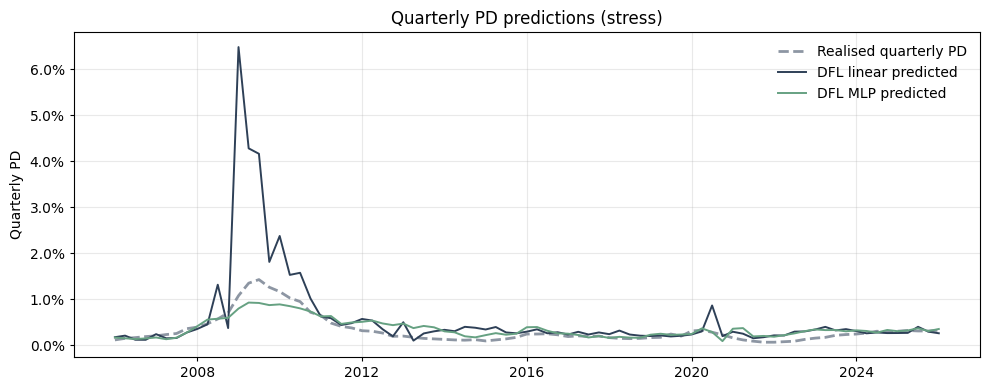

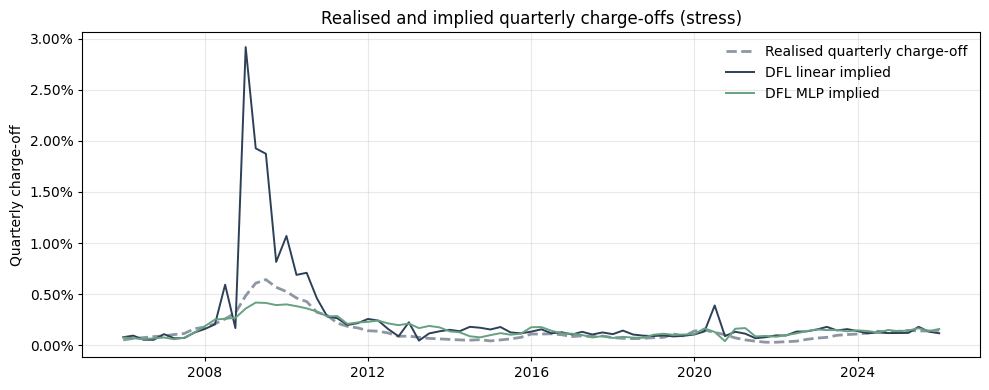

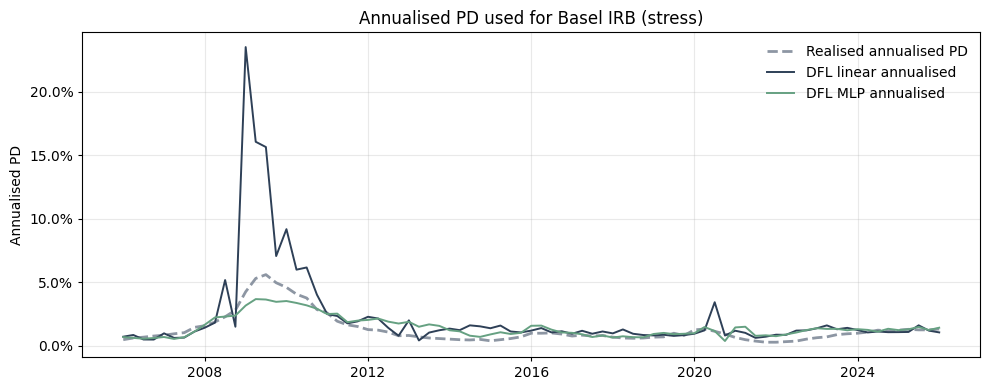

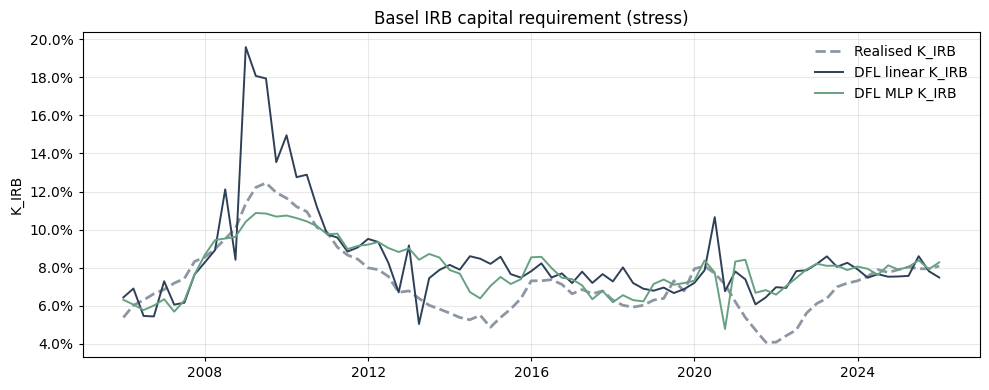

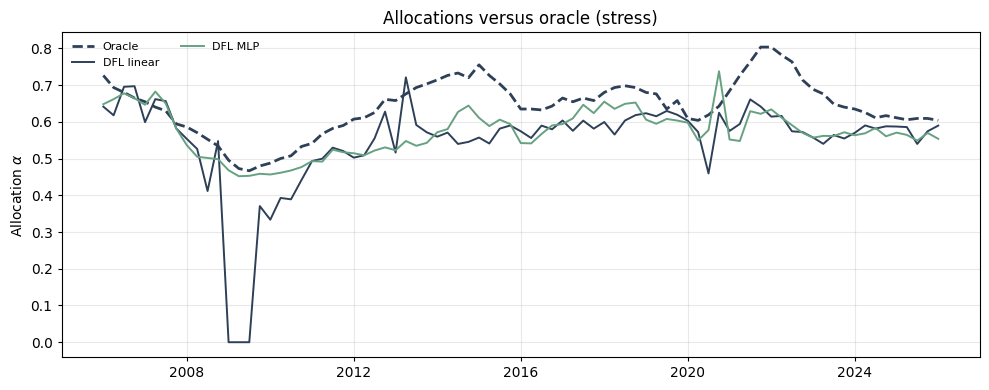

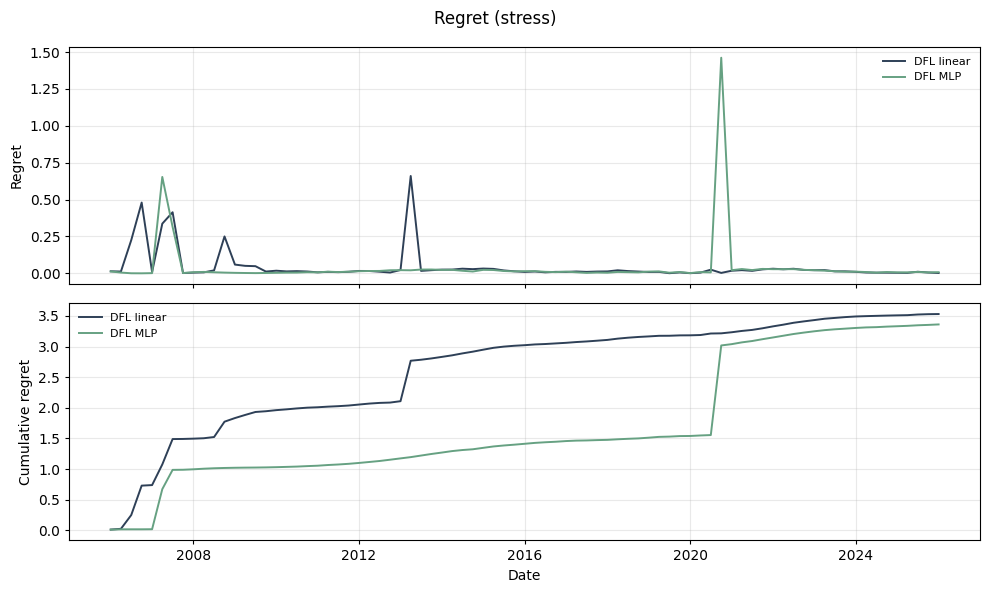

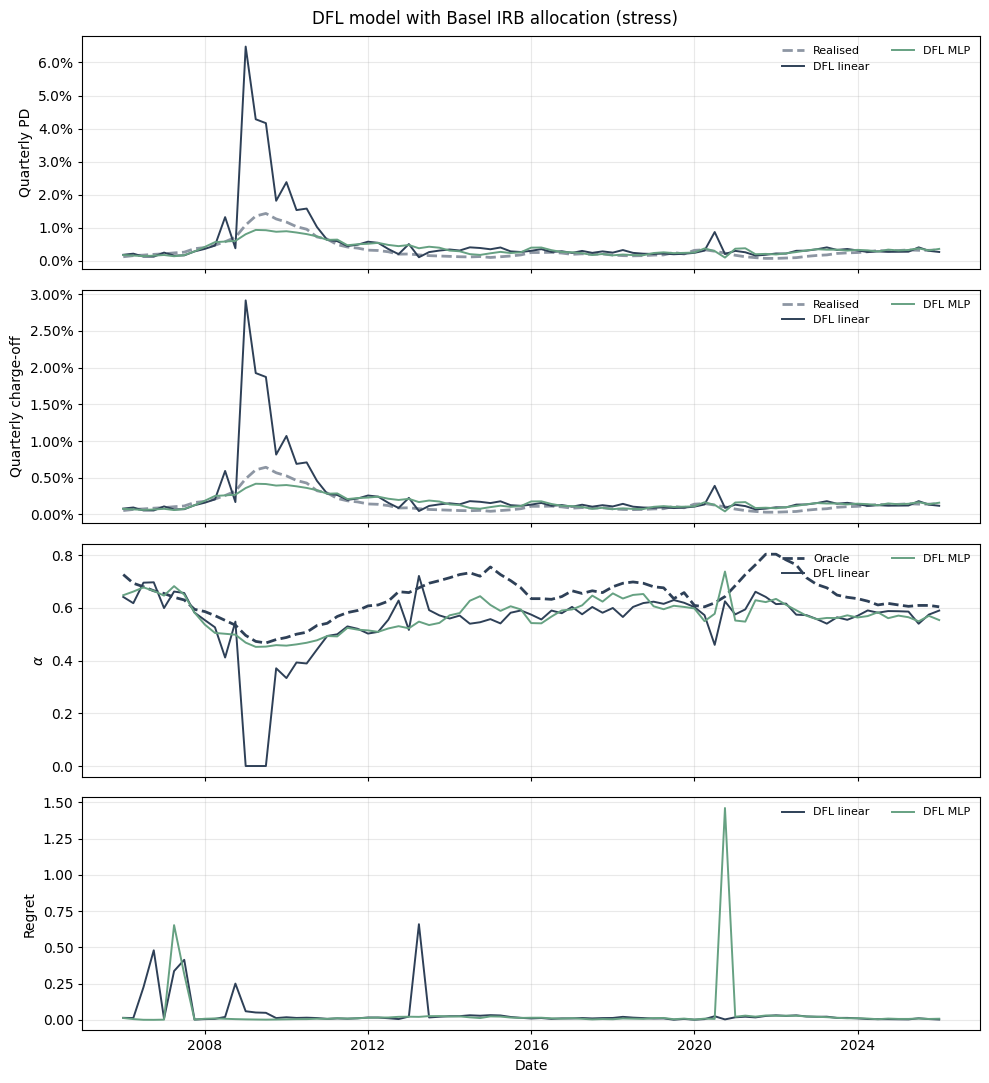

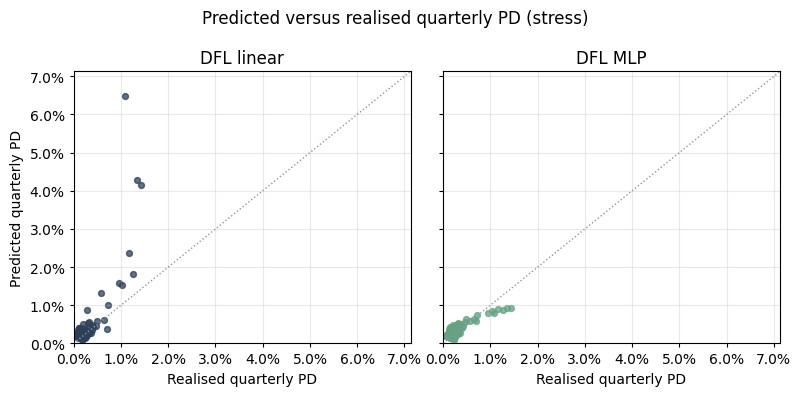

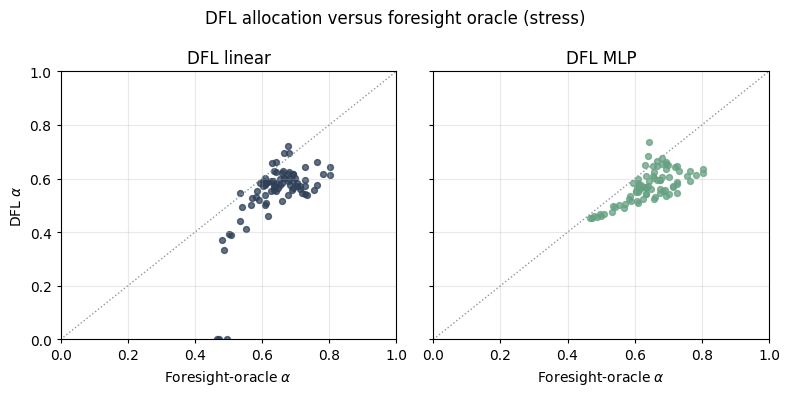

In [23]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
                     "xtick.major.size": 3, "ytick.major.size": 3, "font.sans-serif": ["DejaVu Sans"]})
from minou_colors import MINOU_COLORS
MODEL_COLORS = {"dfl_linear": MINOU_COLORS["navy"], "dfl_mlp": MINOU_COLORS["sage"]}
MODEL_LW = {"dfl_linear": 1.4, "dfl_mlp": 1.4}
MODEL_LABELS = {"dfl_linear": "DFL linear", "dfl_mlp": "DFL MLP"}
ORACLE_COLOR = MINOU_COLORS["navy"]
REAL_COLOR = MINOU_COLORS["grey"]

PLOT_MODELS = ["dfl_linear", "dfl_mlp"]

def format_date_axis(ax, year_step=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(year_step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)


def _model_lines(ax, plot_df, col_prefix, suffix="", models=None):
    for m in (PLOT_MODELS if models is None else models):
        ax.plot(plot_df["date"], plot_df[f"{col_prefix}_{m}"], color=MODEL_COLORS[m],
                lw=MODEL_LW[m], label=f"{MODEL_LABELS[m]}{suffix}")


def plot_split(res, split_name):
    fig_dir = FIGURES_DIR / split_name
    fig_dir.mkdir(parents=True, exist_ok=True)
    plot_df = res.sort_values("date").copy()
    year_step = 2 if len(plot_df) <= 60 else 4

    # 1. Quarterly PD predictions
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["pd_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised quarterly PD")
    _model_lines(ax, plot_df, "pd_q_hat", " predicted")
    ax.set_ylabel("Quarterly PD"); ax.set_title(f"Quarterly PD predictions ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "quarterly_pd_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

    # 2. Quarterly charge-off predictions
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised quarterly charge-off")
    _model_lines(ax, plot_df, "c_q_hat", " implied")
    ax.set_ylabel("Quarterly charge-off"); ax.set_title(f"Realised and implied quarterly charge-offs ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "quarterly_chargeoff_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

    # 3. Annualised PD for IRB
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["pd_a_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised annualised PD")
    _model_lines(ax, plot_df, "pd_a_hat", " annualised")
    ax.set_ylabel("Annualised PD"); ax.set_title(f"Annualised PD used for Basel IRB ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "annualised_pd_irb.png", dpi=200, bbox_inches="tight"); plt.show()

    # 4. IRB capital requirement
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["k_irb_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised K_IRB")
    _model_lines(ax, plot_df, "k_irb_hat", " K_IRB")
    ax.set_ylabel("K_IRB"); ax.set_title(f"Basel IRB capital requirement ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "irb_capital_requirement.png", dpi=200, bbox_inches="tight"); plt.show()

    # 5. Allocation comparison
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(ax, plot_df, "alpha_hat")
    ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title(f"Allocations versus oracle ({split_name})")
    format_date_axis(ax, year_step); ax.legend(frameon=False, fontsize=8, ncol=2); plt.tight_layout()
    plt.savefig(fig_dir / "allocation_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

    # 6. Regret and cumulative regret
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for m in PLOT_MODELS:
        axes[0].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[0].set_ylabel("Regret"); axes[0].legend(frameon=False, fontsize=8)
    axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date"); axes[1].legend(frameon=False, fontsize=8)
    for ax in axes:
        format_date_axis(ax, year_step)
    fig.suptitle(f"Regret ({split_name})"); plt.tight_layout()
    plt.savefig(fig_dir / "regret.png", dpi=200, bbox_inches="tight"); plt.show()

    # 7. Compact 4-panel thesis figure
    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    fig.subplots_adjust(hspace=0.08)
    axes[0].plot(plot_df["date"], plot_df["pd_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
    _model_lines(axes[0], plot_df, "pd_q_hat")
    axes[0].set_ylabel("Quarterly PD"); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
    _model_lines(axes[1], plot_df, "c_q_hat")
    axes[1].set_ylabel("Quarterly charge-off"); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[2].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(axes[2], plot_df, "alpha_hat")
    axes[2].set_ylabel(r"$\alpha$")
    for m in PLOT_MODELS:
        axes[3].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[3].set_ylabel("Regret"); axes[3].set_xlabel("Date")
    for ax in axes:
        format_date_axis(ax, year_step); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=2)
    fig.suptitle(f"DFL model with Basel IRB allocation ({split_name})", fontsize=12)
    plt.tight_layout(); plt.savefig(fig_dir / "dfl_pd_irb_compact_panel.png", dpi=220, bbox_inches="tight"); plt.show()

    # 8. Predicted vs realised scatter
    fig, axes = plt.subplots(1, len(PLOT_MODELS), figsize=(4 * len(PLOT_MODELS), 4), sharex=True, sharey=True)
    lims = [0.0, max(plot_df["pd_q_realised"].max(), *(plot_df[f"pd_q_hat_{m}"].max() for m in PLOT_MODELS)) * 1.1]
    for ax, m in zip(np.atleast_1d(axes), PLOT_MODELS):
        ax.scatter(plot_df["pd_q_realised"], plot_df[f"pd_q_hat_{m}"], s=18, color=MODEL_COLORS[m], alpha=0.75)
        ax.plot(lims, lims, color=MINOU_COLORS["grey"], lw=1, ls=":")
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_title(MODEL_LABELS[m]); ax.set_xlabel("Realised quarterly PD")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.grid(True, alpha=0.28)
    np.atleast_1d(axes)[0].set_ylabel("Predicted quarterly PD")
    fig.suptitle(f"Predicted versus realised quarterly PD ({split_name})")
    plt.tight_layout(); plt.savefig(fig_dir / "pred_vs_realised_scatter.png", dpi=200, bbox_inches="tight"); plt.show()

    # 9. DFL alpha vs oracle alpha scatter
    fig, axes = plt.subplots(1, len(PLOT_MODELS), figsize=(4 * len(PLOT_MODELS), 4), sharex=True, sharey=True)
    for ax, m in zip(np.atleast_1d(axes), PLOT_MODELS):
        ax.scatter(plot_df["alpha_oracle"], plot_df[f"alpha_hat_{m}"], s=18, color=MODEL_COLORS[m], alpha=0.75)
        ax.plot([0, 1], [0, 1], color=MINOU_COLORS["grey"], lw=1, ls=":")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_title(MODEL_LABELS[m]); ax.set_xlabel(r"Foresight-oracle $\alpha$")
        ax.grid(True, alpha=0.28)
    np.atleast_1d(axes)[0].set_ylabel(r"DFL $\alpha$")
    fig.suptitle(f"DFL allocation versus foresight oracle ({split_name})")
    plt.tight_layout(); plt.savefig(fig_dir / "dfl_alpha_vs_oracle_scatter.png", dpi=200, bbox_inches="tight"); plt.show()


for split_name, res in results_by_split.items():
    plot_split(res, split_name)

## Learning curves

Averaged across expanding windows within each split (validation regret - DFL's
early-stopping criterion). Early-stopped windows are padded by carrying the last value
forward so the per-epoch mean has constant composition despite early stopping at
different epochs across windows.

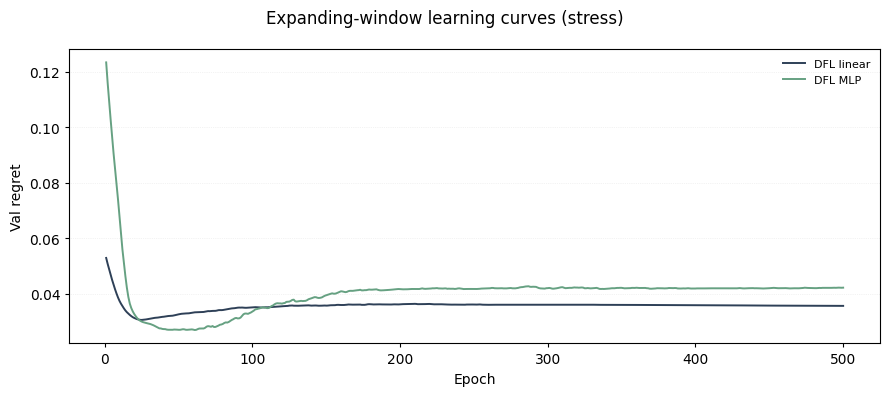

In [24]:
if not training_history.empty:
    for split_name, split_hist in training_history.groupby("split"):
        # Pad each refit's history to the model's max epoch (last value carried forward)
        # so the per-epoch mean has constant composition despite early stopping.
        padded = []
        for model_name, mg in split_hist.groupby("model"):
            max_epoch = int(mg["epoch"].max())
            for _, g in mg.groupby("test_date"):
                gg = (g.sort_values("epoch").set_index("epoch")[["val_loss"]]
                       .reindex(range(1, max_epoch + 1)).ffill().reset_index())
                gg["model"] = model_name
                padded.append(gg)
        mean_history = (pd.concat(padded, ignore_index=True)
                        .groupby(["model", "epoch"], as_index=False)
                        .agg(mean_val_loss=("val_loss", "mean")))

        fig, ax = plt.subplots(figsize=(9, 4))
        for model_name, group in mean_history.groupby("model"):
            group = group.sort_values("epoch"); color = MODEL_COLORS.get(model_name, "grey")
            label = MODEL_LABELS.get(model_name, model_name)
            ax.plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=label)
        ax.set_ylabel("Val regret"); ax.set_xlabel("Epoch")
        ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
        fig.suptitle(f"Expanding-window learning curves ({split_name})"); plt.tight_layout()
        fig_dir = FIGURES_DIR / split_name
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / "learning_curves.png", dpi=200, bbox_inches="tight"); plt.show()